## Quality Processes for Videos

In [1]:
!pip install opencv-python
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importing useful dependencies
import io
import os
import boto3
import cv2

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\SakuraSnow\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\SakuraSnow\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\SakuraSnow\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\

AttributeError: _ARRAY_API not found

In [4]:
# Setup S3 client for MinIO (MinIO implements Amazon S3 API)
s3 = boto3.client(
    "s3",
    endpoint_url="http://localhost:9000", # MinIO API endpoint
    aws_access_key_id="minioadmin", # User name
    aws_secret_access_key="minioadmin", # Password
)

Before preparing/cleaning the data for exploitation zone, we have to perform a quality analysis of the videos stored in the Trusted Zone (Copied from the Formatted Zone). For that purpose, firstly we are going to extract data from each of our videos.

In [5]:
# Given a bucket and a prefix, the function returns a list of data of each video in the target path
def get_data_videos(bucket, prefix=""):

    data = []
    etags=set()
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            
            duplicate = False
            key = obj["Key"]
            size = obj["Size"]
            etag = obj["ETag"].strip('"')
            if size == 0 and key.endswith("/"):
                continue

            # duplication check
            sig = (etag, size)
            if sig in etags:
                duplicate = True
            else:
                etags.add(sig)

            # Download the video
            resp = s3.get_object(Bucket=bucket, Key=key)
            body = resp["Body"].read()

            # Use a temporary file to read the video with OpenCV
            with open("temp_video_in.mp4", "wb") as f:
                f.write(body)

            cv2.VideoCapture()

            cap = cv2.VideoCapture("temp_video_in.mp4")
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = int(cap.get(cv2.CAP_PROP_FPS))
            frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            
            ret, frame = cap.read()
            if ret:
                n_channels = frame.shape[2] if len(frame.shape) == 3 else 1
                mode = 'BGR' if n_channels == 3 else 'GRAY'
            else:
                n_channels = 0
                mode = "N/A"

            cap.release()
            os.remove("temp_video_in.mp4")

            data.append({
                "file_name": key,
                "file_size": obj['Size'] / 1024, # B -> KB
                "width": width,
                "height": height,
                "aspect_ratio": round(width/height, 2) if height > 0 else None,
                "fps": fps,
                "frames": frames,
                "mode": mode,
                "channels": n_channels,
                "duplicated": duplicate
            })

    return data

In [6]:
# Get data from the bucket
data = get_data_videos(bucket = "trusted-zone", prefix = "videos")

In [7]:
# Convert the data into a dataFrame
df_data = pd.DataFrame(data)
df_data.head()

,file_name,file_size,width,height,aspect_ratio,fps,frames,mode,channels,duplicated
0,videos/video_1761689164843.mp4,32733.104492,1280,720,1.78,29,3582,BGR,3,False
1,videos/video_1761689165772.mp4,68250.538086,1920,1080,1.78,60,6059,BGR,3,False
2,videos/video_1761689167102.mp4,57138.572266,1920,1080,1.78,60,4800,BGR,3,False
3,videos/video_1761689168293.mp4,35187.255859,1920,1080,1.78,29,1517,BGR,3,False
4,videos/video_1761689169071.mp4,16812.027344,1920,1080,1.78,29,1649,BGR,3,False


In [8]:
# Have a quick summary of the data
df_data.describe(include="all")

,file_name,file_size,width,height,aspect_ratio,fps,frames,mode,channels,duplicated
count,29,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29,29.0,29
unique,29,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,1
top,videos/video_1761689164843.mp4,NaN,NaN,NaN,NaN,NaN,NaN,BGR,NaN,False
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,29,NaN,29
mean,NaN,41393.089440,1677.241379,947.448276,1.764828,37.551724,3050.413793,NaN,3.0,NaN
std,NaN,21712.873311,359.353552,190.840918,0.083650,14.622845,2314.177446,NaN,0.0,NaN
min,NaN,9476.816406,640.000000,480.000000,1.330000,25.000000,653.000000,NaN,3.0,NaN
25%,NaN,22799.700195,1280.000000,720.000000,1.780000,29.000000,1649.000000,NaN,3.0,NaN
50%,NaN,37329.501953,1920.000000,1080.000000,1.780000,29.000000,2100.000000,NaN,3.0,NaN
75%,NaN,57138.572266,1920.000000,1080.000000,1.780000,59.000000,4205.000000,NaN,3.0,NaN


In [9]:
# Unique values for mode
pd.unique(df_data['mode'])

array(['BGR'], dtype=object)

75% The video files in the dataset are under 60MB in size, while a few files are as big as 190MB. There are also files with errors present given the minimum files size and frame count is 0, indicating at least some files don't contain anything. The vast majority of files are in 16:9 aspect ratio with a few files having narrower aspect ratios going as low as 1:1 (square). Most videos have 3 channels in BGR mode, however there a some files for which the mode could not be determined. 

**Distribution of File Sizes**

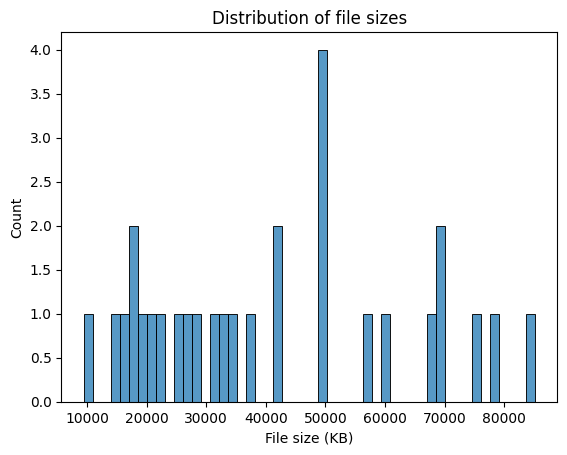

In [10]:
sns.histplot(df_data["file_size"], bins=50)
plt.xlabel("File size (KB)")
plt.ylabel("Count")
plt.title("Distribution of file sizes")
plt.show()

Most videos are under 100MB, with the mean close to 48MB. Very few files are bigger than 150MB.

**Width vs Height of Videos**

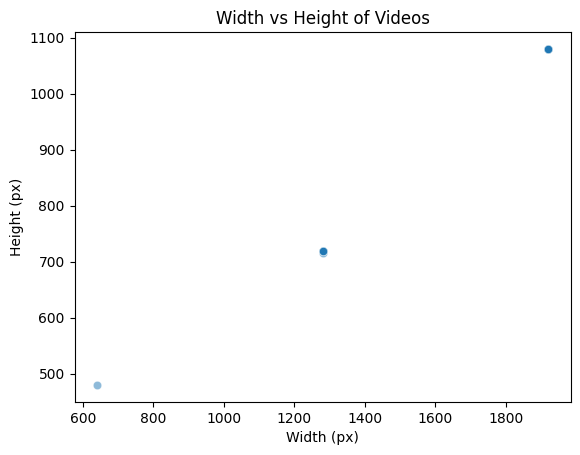

In [11]:
sns.scatterplot(x="width", y="height", data=df_data, alpha=0.5)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Width vs Height of Videos")
plt.show()

Many videos are along a line indicating that they are scales of the same ratio with many data points corresponding to the standard 720p, 1080p and 4k resolutions.

**Aspect Ratio Distribution**

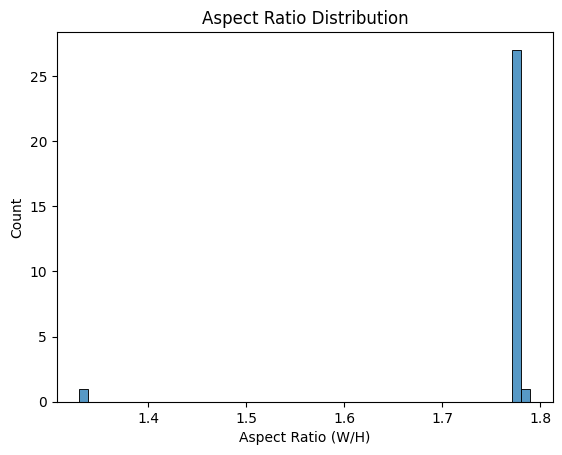

In [12]:
sns.histplot(df_data["aspect_ratio"].dropna(), bins=50)
plt.xlabel("Aspect Ratio (W/H)")
plt.title("Aspect Ratio Distribution")
plt.show()

Here we can see that most videos have a 16:9 resolution, which are the datapoints that fall in a straight line in the previous plot.

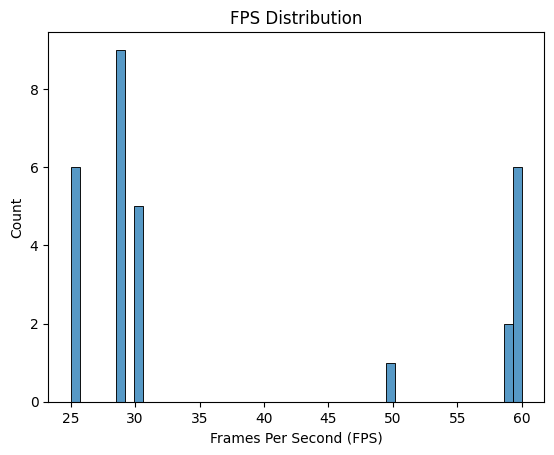

In [13]:
sns.histplot(df_data["fps"].dropna(), bins=50)
plt.xlabel("Frames Per Second (FPS)")
plt.title("FPS Distribution")
plt.show()

The majority of videos are at 30FPS followed by 60FPS, with 24FPS being another popular framerate.

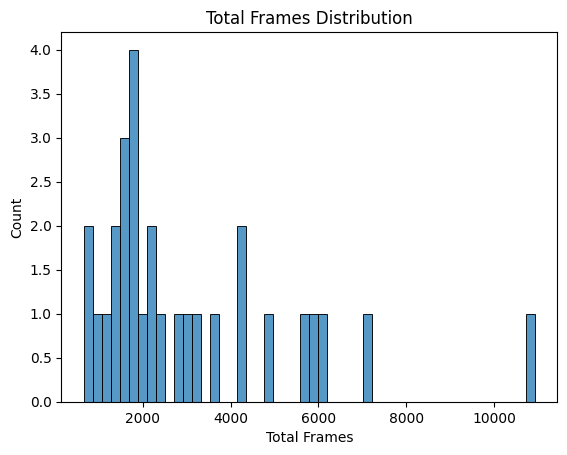

In [14]:
sns.histplot(df_data["frames"].dropna(), bins=50)
plt.xlabel("Total Frames")
plt.title("Total Frames Distribution")
plt.show()

The number of total frames doesn't allow us to deduce duration because the videos have different frame rates, but it does seem similar to the distribution of file sizes.

**Data Cleaning**

Given the statistics of our files we will keep using BGR mode. Event though most videos use 16:9 aspect ratio, they vary in sizes (720p, 1080p, and 4k) and a significan amount of videos are not in this aspect ratio. We will convert the videos to 224x224 resolution which is what the clip4clip model expects. Similarly, given the variations in framerates and in order to reduce the amount of processing needed we will sample the videos at 1FPS which will capture most of the action in the video.

In [15]:
""" Original version
def preprocess_video(bucket, prefix="", target_fps = 1, target_size=(224, 224)):
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]

            if obj['Size'] == 0 and key.endswith("/"): # skip the folder itself
                continue
            
            # Get object metadata to check size
            head = s3.head_object(Bucket=bucket, Key=key)
            if head['ContentLength'] == 0:
                # Delete null video (size = 0)
                s3.delete_object(Bucket=bucket, Key=key)
                continue

            # Download the video
            resp = s3.get_object(Bucket=bucket, Key=key)
            body = resp["Body"].read()
            
            # Copy video to temp file
            in_path = "temp_video_in.mp4"
            with open(in_path, "wb") as f:
                f.write(body)

            cap = cv2.VideoCapture(in_path)
            if not cap.isOpened():
                print(f"Error: Could not open video {key}")
                continue
            FOURCC = cv2.VideoWriter_fourcc(*'mp4v')
            out_path = "temp_video_out.mp4"
            out = cv2.VideoWriter(out_path, FOURCC, 15, target_size)
            if not out.isOpened():
                print(f"Error: Could not open VideoWriter for {key}.")
                continue


            original_fps = int(cap.get(cv2.CAP_PROP_FPS))
            if original_fps == 0:
                print(f"Error: Original FPS is 0. Cannot process {key}")
                continue

            frame_skip = original_fps / target_fps
            if frame_skip < 1:
                frame_skip = 1

            frame_count = 0
            frames_read_count = 0

            while cap.isOpened():
                cap.retrieve
                ret, frame = cap.read()
                if not ret:
                    # End of video file
                    break
        
                frames_read_count += 1
                # 1. Sample
                if frames_read_count % frame_skip == 0:
                    # 2. Resizing
                    frame_resized = cv2.resize(frame, target_size, interpolation=cv2.INTER_AREA)
                    # Add the processed frame to the current segment
                    out.write(frame_resized)
                    frame_count += 1

            cap.release()
            out.release()
            cv2.destroyAllWindows()

            with open(out_path, "rb") as f:
                s3.upload_fileobj(f, Bucket=bucket, Key=key, ExtraArgs={"ContentType": "video/mp4"})

            print(f"Normalized: {key} sampled {frame_count} out of {frames_read_count} frames")
    
    os.remove(in_path)
    os.remove(out_path)
    """

' Original version\ndef preprocess_video(bucket, prefix="", target_fps = 1, target_size=(224, 224)):\n    paginator = s3.get_paginator("list_objects_v2")\n    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):\n        for obj in page.get("Contents", []):\n            key = obj["Key"]\n\n            if obj[\'Size\'] == 0 and key.endswith("/"): # skip the folder itself\n                continue\n\n            # Get object metadata to check size\n            head = s3.head_object(Bucket=bucket, Key=key)\n            if head[\'ContentLength\'] == 0:\n                # Delete null video (size = 0)\n                s3.delete_object(Bucket=bucket, Key=key)\n                continue\n\n            # Download the video\n            resp = s3.get_object(Bucket=bucket, Key=key)\n            body = resp["Body"].read()\n\n            # Copy video to temp file\n            in_path = "temp_video_in.mp4"\n            with open(in_path, "wb") as f:\n                f.write(body)\n\n        

In [16]:
def preprocess_video(client, bucket, prefix="", target_fps = 1, target_size=(224, 224)):
    """
    Normalize and clean video data stored in an S3/MinIO bucket.

    The function analyzes and preprocesses all videos under the given prefix:
    it generates a data quality report, removes corrupted/empty objects and near-duplicate frames,
    extracts frames at a fixed target FPS, converts frames to RGB, resizes them to a fixed target size,
    normalizes pixel values, and re-uploads the outputs to the same bucket.


    client          : obj                   - S3-compatible client (e.g., boto3.client("s3")).
    bucket          : str                   - Target S3/MinIO bucket.
    prefix          : str                   - Optional key prefix (acts like a folder path).
    target_fps      : int                   - Target FPS (int).
    target_size     : tuple[int, int]       - optional Target spatial resolution
    """
    data = get_data_videos( bucket, prefix=prefix)
    df = pd.DataFrame(data) if not isinstance(data, pd.DataFrame) else data.copy()
    if df.empty:
        raise ValueError("No image data to report.")


    in_path = "temp_video_in.mp4"
    out_path = "temp_video_out.mp4"
    print(f"Starting preprocessing for {len(df)} videos (target_fps={target_fps}, target_size={target_size})")

    for row in df.itertuples(index=False):
        # get video name
        key = row.file_name
        # remove empty or duplicated image
        if not key:
            print("Missing file_name; skipping.")
            continue

        if row.duplicated:
            client.delete_object(Bucket=bucket, Key=key)
            print(f"Deleted duplicate: {key}")
            continue



        try:
            # Get object metadata to check size
            head = client.head_object(Bucket=bucket, Key=key)
            if head['ContentLength'] == 0:
                # Delete the null image (size = 0)
                client.delete_object(Bucket=bucket, Key=key)
                print(f"Deleted empty object: {key}")
                continue
        except Exception as e:
            print(f"head_object failed for {key}: {e}")
            continue

        try:
            # Download the video
            resp = client.get_object(Bucket=bucket, Key=key)
            body = resp["Body"].read()

            # Copy video to temp file

            with open(in_path, "wb") as f:
                f.write(body)
            print(f"Downloaded {key} ({len(body)} bytes) to {in_path}")

            cap = cv2.VideoCapture(in_path)
            if not cap.isOpened():
                print(f"Could not open video: {key}")
                continue

            FOURCC = cv2.VideoWriter_fourcc(*'mp4v')

            out = cv2.VideoWriter(out_path, FOURCC, 15, target_size)
            if not out.isOpened():
                print(f"Could not open VideoWriter for {key}")
                cap.release()
                continue

            original_fps = int(cap.get(cv2.CAP_PROP_FPS))
            if original_fps == 0:
                print(f"Invalid original FPS for {key}")
                cap.release()
                out.release()
                continue

            # Accumulator-based sampling: avoids float modulo artifacts
            acc = 0.0
            frame_count = 0
            frames_read_count = 0


            # Read frames, sample at target_fps in time domain, then resize and write out
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                frames_read_count += 1
                acc += target_fps  # advance in "target time units"

                # Sample a frame whenever accumulated target units exceed original FPS
                if acc >= original_fps:
                    acc -= original_fps
                    # INTER_AREA is generally better for downscaling
                    frame_resized = cv2.resize(frame, tuple(target_size), interpolation=cv2.INTER_AREA)
                    out.write(frame_resized)
                    frame_count += 1

            cap.release()
            out.release()
            cv2.destroyAllWindows()

            # Upload normalized output back to the same key
            with open(out_path, "rb") as f:
                client.upload_fileobj(f, Bucket=bucket, Key=key, ExtraArgs={"ContentType": "video/mp4"})

            print(f"Normalized: {key} sampled {frame_count} out of {frames_read_count} frames")

        except Exception as e:
            print(f"Failed to normalize {key}: {e}")

    os.remove(in_path)
    os.remove(out_path)

In [17]:
# Standardizing videos
preprocess_video(s3, bucket = "trusted-zone", prefix = "videos/", target_size = (224,224))

Starting preprocessing for 29 videos (target_fps=1, target_size=(224, 224))
Downloaded videos/video_1761689164843.mp4 (33518699 bytes) to temp_video_in.mp4
Normalized: videos/video_1761689164843.mp4 sampled 123 out of 3582 frames
Downloaded videos/video_1761689165772.mp4 (69888551 bytes) to temp_video_in.mp4
Normalized: videos/video_1761689165772.mp4 sampled 100 out of 6059 frames
Downloaded videos/video_1761689167102.mp4 (58509898 bytes) to temp_video_in.mp4
Normalized: videos/video_1761689167102.mp4 sampled 80 out of 4800 frames
Downloaded videos/video_1761689168293.mp4 (36031750 bytes) to temp_video_in.mp4
Normalized: videos/video_1761689168293.mp4 sampled 52 out of 1517 frames
Downloaded videos/video_1761689169071.mp4 (17215516 bytes) to temp_video_in.mp4
Normalized: videos/video_1761689169071.mp4 sampled 56 out of 1649 frames
Downloaded videos/video_1761689169535.mp4 (77758494 bytes) to temp_video_in.mp4
Normalized: videos/video_1761689169535.mp4 sampled 111 out of 3224 frames
Dow

In [18]:
# Get data from the bucket
norm_data = get_data_videos(bucket = "trusted-zone", prefix = "videos")
# Convert the data into a dataFrame
df_norm_data = pd.DataFrame(norm_data)
df_norm_data.head()
# Have a quick summary of the data
df_norm_data.describe(include="all")

,file_name,file_size,width,height,aspect_ratio,fps,frames,mode,channels,duplicated
count,29,29.000000,29.0,29.0,29.0,29.0,29.000000,29,29.0,29
unique,29,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,1
top,videos/video_1761689164843.mp4,NaN,NaN,NaN,NaN,NaN,NaN,BGR,NaN,False
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,29,NaN,29
mean,NaN,572.083816,224.0,224.0,1.0,15.0,77.172414,NaN,3.0,NaN
std,NaN,454.211151,0.0,0.0,0.0,0.0,40.868316,NaN,0.0,NaN
min,NaN,107.046875,224.0,224.0,1.0,15.0,26.000000,NaN,3.0,NaN
25%,NaN,251.644531,224.0,224.0,1.0,15.0,52.000000,NaN,3.0,NaN
50%,NaN,445.277344,224.0,224.0,1.0,15.0,70.000000,NaN,3.0,NaN
75%,NaN,778.695312,224.0,224.0,1.0,15.0,100.000000,NaN,3.0,NaN
